# Visualización del Rendimiento del Modelo Champion
## Apple (AAPL) - Año 2026

Este notebook carga los resultados de las operaciones simuladas con el modelo **Champion** (XGBoost con sentimientos) y genera los gráficos comparativos de señales de trading, evolución del capital, drawdowns y retornos acumulados de acuerdo con el esquema del notebook original.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

# Configuración de estilo para gráficos
plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("husl")

# Ruta del archivo
csv_path = "../docs/AAPL_trading.csv"

if not os.path.exists(csv_path):
    # Fallback si se ejecuta desde la raíz del proyecto
    csv_path = "docs/AAPL_trading.csv"

print(f"Cargando datos desde: {csv_path}")
df = pd.read_csv(csv_path)
df["date"] = pd.to_datetime(df["date"])
df.set_index("date", inplace=True)
print("Datos cargados correctamente. Filas:", len(df))

Cargando datos desde: ../docs/AAPL_trading.csv
Datos cargados correctamente. Filas: 123


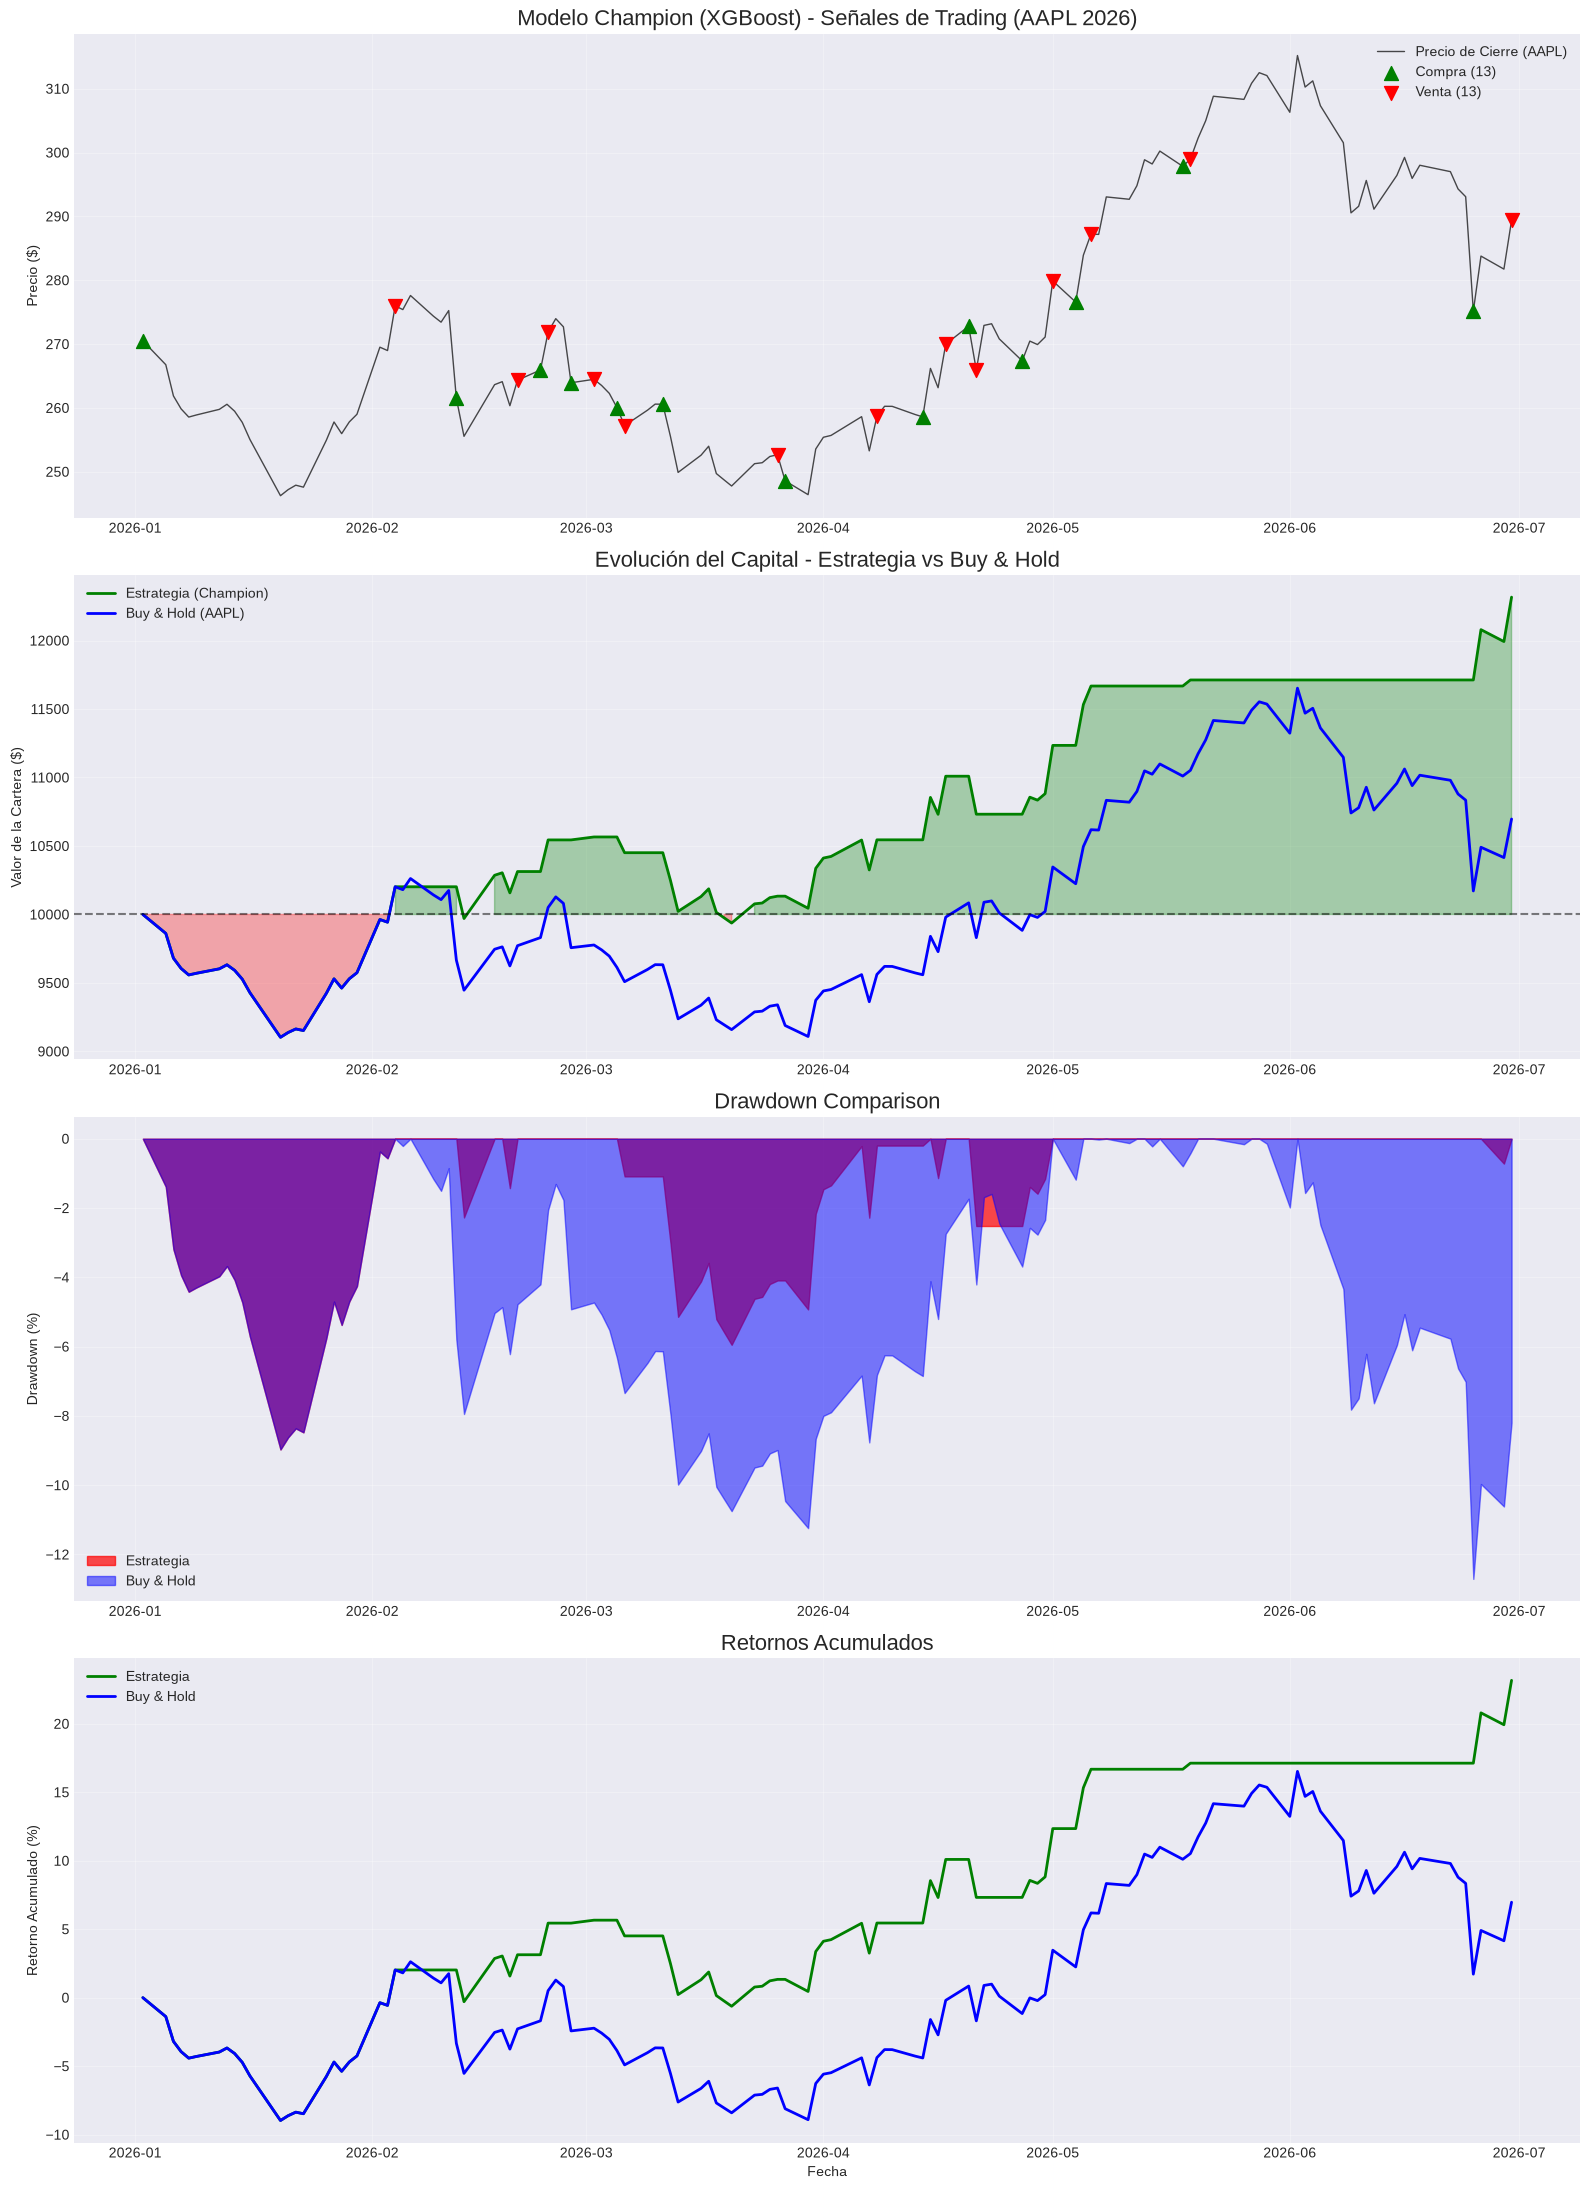

In [2]:
# Definir parámetros
capital_inicial = 10000.0  # El archivo AAPL_trading.csv empieza con $10,000 USD

# Generar la visualización del backtesting (4 paneles)
fig, axes = plt.subplots(4, 1, figsize=(16, 22))

# 1. Close Price and Signals
ax1 = axes[0]
ax1.plot(
    df.index,
    df["price_close"],
    label="Precio de Cierre (AAPL)",
    color="black",
    alpha=0.7,
    linewidth=1,
)

# Marcar señales de compra y venta
buy_signals = df[df["Buy_Signal"] == True]
sell_signals = df[df["Sell_Signal"] == True]

ax1.scatter(
    buy_signals.index,
    buy_signals["price_close"],
    color="green",
    marker="^",
    s=100,
    label=f"Compra ({len(buy_signals)})",
    zorder=5,
)
ax1.scatter(
    sell_signals.index,
    sell_signals["price_close"],
    color="red",
    marker="v",
    s=100,
    label=f"Venta ({len(sell_signals)})",
    zorder=5,
)

ax1.set_title("Modelo Champion (XGBoost) - Señales de Trading (AAPL 2026)", fontsize=16)
ax1.set_ylabel("Precio ($)")
ax1.legend(loc="best")
ax1.grid(True, alpha=0.3)

# 2. Equity Curves
ax2 = axes[1]
ax2.plot(
    df.index,
    df["Strategy_Equity"],
    label="Estrategia (Champion)",
    color="green",
    linewidth=2,
)
ax2.plot(
    df.index,
    df["Buy_Hold_Equity"],
    label="Buy & Hold (AAPL)",
    color="blue",
    linewidth=2,
)
ax2.fill_between(
    df.index,
    capital_inicial,
    df["Strategy_Equity"],
    where=(df["Strategy_Equity"] > capital_inicial),
    color="green",
    alpha=0.3,
)
ax2.fill_between(
    df.index,
    capital_inicial,
    df["Strategy_Equity"],
    where=(df["Strategy_Equity"] <= capital_inicial),
    color="red",
    alpha=0.3,
)
ax2.axhline(y=capital_inicial, color="black", linestyle="--", alpha=0.5)
ax2.set_title("Evolución del Capital - Estrategia vs Buy & Hold", fontsize=16)
ax2.set_ylabel("Valor de la Cartera ($)")
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. Drawdowns
ax3 = axes[2]
rolling_max_est = df["Strategy_Equity"].expanding().max()
drawdown_est = (df["Strategy_Equity"] - rolling_max_est) / rolling_max_est * 100
rolling_max_bh = df["Buy_Hold_Equity"].expanding().max()
drawdown_bh = (df["Buy_Hold_Equity"] - rolling_max_bh) / rolling_max_bh * 100

ax3.fill_between(df.index, 0, drawdown_est, color="red", alpha=0.7, label="Estrategia")
ax3.fill_between(df.index, 0, drawdown_bh, color="blue", alpha=0.5, label="Buy & Hold")
ax3.set_title("Drawdown Comparison", fontsize=16)
ax3.set_ylabel("Drawdown (%)")
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. Cumulative Returns
ax4 = axes[3]
cum_returns_est = (1 + df["Strategy_Returns"]).cumprod() - 1
cum_returns_bh = (1 + df["Returns"]).cumprod() - 1

ax4.plot(
    df.index, cum_returns_est * 100, label="Estrategia", color="green", linewidth=2
)
ax4.plot(df.index, cum_returns_bh * 100, label="Buy & Hold", color="blue", linewidth=2)
ax4.set_title("Retornos Acumulados", fontsize=16)
ax4.set_ylabel("Retorno Acumulado (%)")
ax4.set_xlabel("Fecha")
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [3]:
# Mostrar tabla comparativa de métricas
retorno_total_bh = (df["Buy_Hold_Equity"].iloc[-1] / capital_inicial - 1) * 100
retorno_total_est = (df["Strategy_Equity"].iloc[-1] / capital_inicial - 1) * 100

sharpe_bh = np.sqrt(252) * df["Returns"].mean() / df["Returns"].std()
sharpe_est = np.sqrt(252) * df["Strategy_Returns"].mean() / df["Strategy_Returns"].std()

max_drawdown_bh = (
    (df["Buy_Hold_Equity"] - df["Buy_Hold_Equity"].expanding().max())
    / df["Buy_Hold_Equity"].expanding().max()
).min() * 100
max_drawdown_est = (
    (df["Strategy_Equity"] - df["Strategy_Equity"].expanding().max())
    / df["Strategy_Equity"].expanding().max()
).min() * 100

metricas = {
    "Buy & Hold": {
        "Retorno Total (%)": retorno_total_bh,
        "Sharpe Ratio": sharpe_bh,
        "Max Drawdown (%)": max_drawdown_bh,
    },
    "Estrategia": {
        "Retorno Total (%)": retorno_total_est,
        "Sharpe Ratio": sharpe_est,
        "Max Drawdown (%)": max_drawdown_est,
        "Número de Trades": df["Buy_Signal"].sum(),
    },
}

df_metricas = pd.DataFrame(metricas).T
print("📊 MÉTRICAS DE RENDIMIENTO (2026)")
print("=" * 60)
print(df_metricas.round(2))

📊 MÉTRICAS DE RENDIMIENTO (2026)
            Retorno Total (%)  Sharpe Ratio  Max Drawdown (%)  \
Buy & Hold               6.97          0.66            -12.71   
Estrategia              23.17          2.35             -8.97   

            Número de Trades  
Buy & Hold               NaN  
Estrategia              13.0  
